#ePGD DL & GENAI: Assignment (Apr 2026)
# Sem II - Ashish Trivedi
##Part B: Recurrent Neural Networks (Sentiment Classification)
### Dataset from  IMDB Large Movie Review Dataset - https://ai.stanford.edu/~amaas/data/sentiment/
#### Problem Description:
##### Consider the task of sentiment classification using a standard natural language processing dataset. The objective of this part is to study and compare the effectiveness of different recurrent neural network architectures, namely vanilla recurrent neural networks (RNNs), long short-term memory networks (LSTMs), and attention-augmented variants, for binary sentiment classification.
##### Use the IMDB Large Movie Review Dataset, which consists of English movie reviews annotated with binary sentiment labels (positive or negative). Each input sample is a sequence of tokens corresponding to a review, and the model output is a single sentiment label.

## B1-1 ▶ import gz file and extract to workspace.


In [1]:
# B1 - 1
import os
import pandas as pd
import tarfile
import urllib.request

# URL for the IMDB dataset
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
archive_name = "aclImdb_v1.tar.gz"
extracted_folder = "aclImdb"

digi_s = []
digi_s.append('B1-A')
# Download the dataset if not already present
if not os.path.exists(archive_name):
    print(f"Downloading {archive_name}...")
    urllib.request.urlretrieve(url, archive_name)
    print("Download complete.")

# Extract the dataset if not already extracted
if not os.path.exists(extracted_folder):
    print(f"Extracting {extracted_folder}...")
    with tarfile.open(archive_name, "r:gz") as tar:
        tar.extractall()
    print("Extraction complete.")

# Function to load data from a given path
def load_imdb_data(path):
    data = []
    for label_type in ['pos', 'neg']:
        label = 1 if label_type == 'pos' else 0
        dir_path = os.path.join(path, label_type)
        for fname in os.listdir(dir_path):
            if fname.endswith('.txt'):
                with open(os.path.join(dir_path, fname), 'r', encoding='utf-8') as f:
                    data.append({'text': f.read(), 'label': label})
    return pd.DataFrame(data)

# Load training and testing data
train_df = load_imdb_data(os.path.join(extracted_folder, 'train'))
test_df = load_imdb_data(os.path.join(extracted_folder, 'test'))

print("First 5 training samples:")
for i, row in train_df.head(5).iterrows():
    print(f"Sample {i+1}:\n  Label: {'Positive' if row['label'] == 1 else 'Negative'}\n  Text: {row['text'][:150]}...\n")

print("\nFirst 5 testing samples:")
for i, row in test_df.head(5).iterrows():
    print(f"Sample {i+1}:\n  Label: {'Positive' if row['label'] == 1 else 'Negative'}\n  Text: {row['text'][:150]}...\n")

First 5 training samples:
Sample 1:
  Label: Positive
  Text: After Fatih Akins first work "Im Juli", which was fairly good, he created a really gorgeous italian family epic. Its a german movie, which is unfortun...

Sample 2:
  Label: Positive
  Text: When I saw this film in the 1950s, I wanted to be a scientist too. There was something magical and useful in Science. I took a girl - friend along to ...

Sample 3:
  Label: Positive
  Text: After hitting the viewers with three very different episodes right off the bat, Serling continued to go about introducing viewers to 'The Twilight Zon...

Sample 4:
  Label: Positive
  Text: God! Zorro has been the the subject of about as many movies as Tarzan, and probably had about as many actors in the title role. <br /><br />This Seria...

Sample 5:
  Label: Positive
  Text: Okay, I know I shouldn't like this movie but I do. From Pat Morita's loveable interpretation of a Japanese stereotype to Jay Leno's annoying yell, I l...


First 5 testing sa

In [2]:
# print(' train len ', train_df.__len__()) # value 25,000 for this IMDB dataset
# print(' test len ', test_df.__len__())   # value 25,000 for this IMDB dataset

## B1 ▶ Text Preprocessing

In [3]:
# B1 - 2
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
    # Also try to find punkt_tab, as it seems to be specifically requested
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt')
    # Explicitly download punkt_tab if punkt alone isn't enough
    try:
        nltk.data.find('tokenizers/punkt_tab')
    except LookupError:
        nltk.download('punkt_tab')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

print("NLTK data (stopwords, punkt, wordnet, punkt_tab) downloaded/checked.")

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Normalization: Convert to lowercase and remove HTML tags/punctuation
    text = text.lower() # Convert to lowercase
    text = re.sub(r'<.*?>', '', text) # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove punctuation and numbers

    # 2. Tokenization: Split into individual words
    tokens = word_tokenize(text)

    # 3. Redundancy Reduction (Lemmatization) and Stop-word Removal
    processed_tokens = []
    for word in tokens:
        if word not in stop_words:
            processed_tokens.append(lemmatizer.lemmatize(word))

    return ' '.join(processed_tokens)

print("Text preprocessing function defined.")

NLTK data (stopwords, punkt, wordnet, punkt_tab) downloaded/checked.
Text preprocessing function defined.


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Now, let's apply the `preprocess_text` function to the 'text' column of both `train_df` and `test_df`.

In [4]:
# B1 - 3
# Apply the preprocessing function
train_df['processed_text'] = train_df['text'].apply(preprocess_text)
test_df['processed_text'] = test_df['text'].apply(preprocess_text)

print("Preprocessing complete for training and testing data.")

# Display a sample of processed text
print("\nSample of processed training text:")
for i, row in train_df.head(2).iterrows():
    print(f"Original: {row['text'][:100]}...")
    print(f"Processed: {row['processed_text'][:100]}...")

print("\nSample of processed testing text:")
for i, row in test_df.head(2).iterrows():
    print(f"Original: {row['text'][:100]}...")
    print(f"Processed: {row['processed_text'][:100]}...")

Preprocessing complete for training and testing data.

Sample of processed training text:
Original: After Fatih Akins first work "Im Juli", which was fairly good, he created a really gorgeous italian ...
Processed: fatih akins first work im juli fairly good created really gorgeous italian family epic german movie ...
Original: When I saw this film in the 1950s, I wanted to be a scientist too. There was something magical and u...
Processed: saw film wanted scientist something magical useful science took girl friend along see second time do...

Sample of processed testing text:
Original: I just watched this movie at the Santo Domingo International Film Festival. While watching the movie...
Processed: watched movie santo domingo international film festival watching movie feeling seen movie similar st...
Original: This tough-to-see little picture played at the Mods & Rockers 2007 festival. It is a wonderful and l...
Processed: toughtosee little picture played mod rocker festival wonderful 

## B1 Summary: Data Loading and Preprocessing

This section focused on preparing the IMDB movie review dataset for sentiment classification. The key steps included:

1.  **Data Acquisition:** The `aclImdb_v1.tar.gz` dataset was downloaded from Stanford's website and extracted to the local environment. This dataset contains 50,000 movie reviews, evenly split between positive and negative sentiments (25,000 training, 25,000 testing).

2.  **Data Loading:** Custom functions were used to load the positive and negative review text files into pandas DataFrames, `train_df` and `test_df`, each with 'text' and 'label' columns.

3.  **Text Preprocessing:** A `preprocess_text` function was defined and applied to all review texts. This function performed the following critical steps:
    *   **Normalization:** Converted text to lowercase and removed HTML tags and punctuation.
    *   **Tokenization:** Broke down the text into individual words (tokens).
    *   **Redundancy Reduction & Stop-word Removal:** Applied lemmatization to reduce words to their base form and removed common English stop words (e.g., 'the', 'is', 'a') to focus on more meaningful terms.

This preprocessing ensures that the text data is clean, consistent, and ready for numerical representation in subsequent modeling steps.

In [5]:
# B1 - 4 (Extra)
# print("\n--- Sample from Training Data ---")

# Get 3 positive training reviews
# positive_train_reviews = train_df[train_df['label'] == 1].sample(3, random_state=42)
# print("\n3 Positive Training Reviews:")
# for i, row in positive_train_reviews.iterrows():
#     print(f"  Review {i+1}: {row['text'][:200]}...")

# Get 3 negative training reviews
# negative_train_reviews = train_df[train_df['label'] == 0].sample(3, random_state=42)
# print("\n3 Negative Training Reviews:")
# for i, row in negative_train_reviews.iterrows():
#     print(f"  Review {i+1}: {row['text'][:200]}...")

# print("\n--- Sample from Testing Data ---")

# Get 3 positive testing reviews
# positive_test_reviews = test_df[test_df['label'] == 1].sample(3, random_state=42)
# print("\n3 Positive Testing Reviews:")
# for i, row in positive_test_reviews.iterrows():
#     print(f"  Review {i+1}: {row['text'][:200]}...")

# Get 3 negative testing reviews
# negative_test_reviews = test_df[test_df['label'] == 0].sample(3, random_state=42)
# print("\n3 Negative Testing Reviews:")
# for i, row in negative_test_reviews.iterrows():
#     print(f"  Review {i+1}: {row['text'][:200]}...")

## B2 ▶ token mapping of vocabulary generated from previous data.

In [6]:
!pip install gensim

In [7]:
# B2 1
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from gensim.models import Word2Vec
import os

# --- 1. Data Splitting ---
# Features are the processed text, labels are the sentiment (0 or 1)
X = train_df['processed_text']
y = train_df['label']

# Split the training data into training and validation sets
# Using an 80/20 split for training/validation
X_train_text, X_val_text, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Prepare the test data
X_test_text = test_df['processed_text']
y_test = test_df['label']

print("Data split into training, validation, and test sets.")
print(f"Shape of X_train_text: {X_train_text.shape}")
print(f"Shape of X_val_text: {X_val_text.shape}")
print(f"Shape of X_test_text: {X_test_text.shape}")

# --- 2. Vocabulary Construction and Token to Index Mapping ---
# Combine all processed text to build the vocabulary
all_processed_text = pd.concat([X_train_text, X_val_text, X_test_text])
digi_s.append('B2-S')

# Initialize Tokenizer
# num_words: the maximum number of words to keep, based on word frequency.
# filter: a string where each element is a character that will be filtered from the texts.
# lower: boolean. Whether to convert the texts to lowercase.
# oov_token: if given, it will be added to word_index and used to replace out-of-vocabulary words during text_to_sequence calls.

# Let's set num_words to None initially to get the full vocabulary, then we can decide.
tokenizer = Tokenizer(oov_token="<unk>") # Using <unk> for out-of-vocabulary words
tokenizer.fit_on_texts(all_processed_text)

word_index = tokenizer.word_index
vocabulary_size = len(word_index) + 1 # +1 for padding index 0, or OOV token if oov_token is not used for 0

print(f"\nVocabulary size: {vocabulary_size} unique tokens.")
print(f"Sample word_index entries: {list(word_index.items())[:10]}")

# Convert text sequences to integer sequences
X_train_sequences = tokenizer.texts_to_sequences(X_train_text)
X_val_sequences = tokenizer.texts_to_sequences(X_val_text)
X_test_sequences = tokenizer.texts_to_sequences(X_test_text)

print("\nText converted to integer sequences.")
print(f"Sample X_train_sequences[0][:5]: {X_train_sequences[0][:5]}")

# --- 3. Determine Sequence Length and Padding ---
# Calculate average and max sequence length to inform maxlen choice
all_lengths = [len(seq) for seq in X_train_sequences + X_val_sequences + X_test_sequences]
max_sequence_length = max(all_lengths)
avg_sequence_length = int(np.mean(all_lengths))

# Choose a max_sequence_length (e.g., 250 or a value covering most reviews)
# For RNNs, it's common to pick a fixed length. Reviews longer than this will be truncated,
# and shorter ones will be padded.
sequence_length = 250 # A common choice for movie review sentiment analysis

# Pad sequences
X_train_padded = pad_sequences(X_train_sequences, maxlen=sequence_length, padding='post', truncating='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=sequence_length, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=sequence_length, padding='post', truncating='post')

print(f"\nMax sequence length observed: {max_sequence_length}")
print(f"Average sequence length observed: {avg_sequence_length}")
print(f"Selected sequence length for padding: {sequence_length}")
print(f"Shape of X_train_padded: {X_train_padded.shape}")
print(f"Sample X_train_padded[0]: {X_train_padded[0][:10]}...")

# --- 4. Embedding Preparations ---

# One-Hot Encoding (Conceptual explanation)
print("\n--- One-Hot Encoding ---")
print("One-hot encoding for text data means each word is represented by a vector of size 'vocabulary_size', ")
print("where a '1' is placed at the index corresponding to the word and '0's elsewhere.")
print("This is generally not used directly as an input layer for RNNs due to its high dimensionality and sparsity,")
print("but the integer indices generated by the tokenizer are the foundation for one-hot representations or embedding lookups.")
print(f"When conceptualizing one-hot, the embedding dimension would be {vocabulary_size}.")


# Word2Vec Embeddings
print("\n--- Word2Vec Embeddings ---")
embedding_dim_w2v = 100 # Common embedding dimension for Word2Vec

# Prepare corpus for Word2Vec (list of lists of words)
w2v_corpus = [review.split() for review in all_processed_text]

# Train Word2Vec model
w2v_model = Word2Vec(sentences=w2v_corpus, vector_size=embedding_dim_w2v, window=5, min_count=1, workers=4)

# Create an embedding matrix for our vocabulary
embedding_matrix_w2v = np.zeros((vocabulary_size, embedding_dim_w2v))
for word, i in word_index.items():
    if word in w2v_model.wv:
        embedding_matrix_w2v[i] = w2v_model.wv[word]

print(f"Word2Vec embedding dimension: {embedding_dim_w2v}")
print(f"Shape of Word2Vec embedding matrix: {embedding_matrix_w2v.shape}")


# --- Final State Summary ---
print("\n--- Summary of Parameters ---")
print(f"Vocabulary Size: {vocabulary_size}")
print(f"Selected Sequence Length: {sequence_length}")
print(f"One-Hot Encoding Dimension (conceptual): {vocabulary_size}")
print(f"Word2Vec Embedding Dimension: {embedding_dim_w2v}")


Data split into training, validation, and test sets.
Shape of X_train_text: (20000,)
Shape of X_val_text: (5000,)
Shape of X_test_text: (25000,)

Vocabulary size: 203436 unique tokens.
Sample word_index entries: [('<unk>', 1), ('movie', 2), ('film', 3), ('one', 4), ('like', 5), ('time', 6), ('good', 7), ('character', 8), ('get', 9), ('even', 10)]

Text converted to integer sequences.
Sample X_train_sequences[0][:5]: [75, 31, 362, 204, 4934]

Max sequence length observed: 1420
Average sequence length observed: 118
Selected sequence length for padding: 250
Shape of X_train_padded: (20000, 250)
Sample X_train_padded[0]: [   75    31   362   204  4934 27682    24     6  2925   382]...

--- One-Hot Encoding ---
One-hot encoding for text data means each word is represented by a vector of size 'vocabulary_size', 
where a '1' is placed at the index corresponding to the word and '0's elsewhere.
This is generally not used directly as an input layer for RNNs due to its high dimensionality and spa

In [8]:
import urllib.request
import zipfile

# GloVe Embeddings
print("\n--- GloVe Embeddings ---")
embedding_dim_glove = 100 # Match Word2Vec dimension for comparison, or use 50, 200, 300

# Download GloVe embeddings (if not already present)
glove_url = "http://nlp.stanford.edu/data/glove.6B.zip"
glove_zip_path = "glove.6B.zip"
glove_extracted_path = "glove.6B.{}d.txt".format(embedding_dim_glove)

if not os.path.exists(glove_extracted_path):
    print(f"Downloading GloVe embeddings ({embedding_dim_glove}d). This may take a while...")
    if not os.path.exists(glove_zip_path):
        urllib.request.urlretrieve(glove_url, glove_zip_path)

    with zipfile.ZipFile(glove_zip_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    print("GloVe extraction complete.")

# Load GloVe embeddings
glove_embeddings = {}
with open(glove_extracted_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = vector

# Create GloVe embedding matrix for our vocabulary
embedding_matrix_glove = np.zeros((vocabulary_size, embedding_dim_glove))
for word, i in word_index.items():
    embedding_vector = glove_embeddings.get(word)
    if embedding_vector is not None:
        embedding_matrix_glove[i] = embedding_vector

print(f"GloVe embedding dimension: {embedding_dim_glove}")
print(f"Shape of GloVe embedding matrix: {embedding_matrix_glove.shape}")



--- GloVe Embeddings ---
GloVe embedding dimension: 100
Shape of GloVe embedding matrix: (203436, 100)


## B2 Summary: Token Mapping and Embedding Preparation

This section focused on converting the preprocessed text into numerical representations suitable for neural networks, and preparing various embedding strategies.

1.  **Data Splitting:** The initial `train_df` was further split into training and validation sets (80/20 ratio) to monitor model performance during training and prevent overfitting. The `test_df` was kept separate for final evaluation.

2.  **Vocabulary Construction & Tokenization:**
    *   A `Tokenizer` from Keras was fitted on all processed text (train, validation, and test) to build a comprehensive vocabulary.
    *   An `<unk>` token was used to handle out-of-vocabulary words.
    *   The total vocabulary size identified was **203,436** unique tokens.
    *   All text reviews were converted into integer sequences based on this tokenizer.

3.  **Sequence Padding:**
    *   The `max_sequence_length` observed was 1420, with an average of 118 words per review.
    *   A fixed `sequence_length` of **250** was chosen for padding, meaning reviews longer than 250 tokens were truncated, and shorter ones were padded with zeros.
    *   This results in padded input arrays like `X_train_padded` with shape (20000, 250).

4.  **Embedding Preparations:**
    *   **One-Hot Encoding (Conceptual):** Explained as a high-dimensional, sparse representation, generally not practical for direct use in RNNs.
    *   **Word2Vec Embeddings:**
        *   A Word2Vec model was trained directly on the processed text corpus, resulting in `embedding_dim_w2v = 100` dimensional vectors.
        *   An `embedding_matrix_w2v` of shape (203436, 100) was created, mapping each word in our vocabulary to its Word2Vec vector.
    *   **GloVe Embeddings:**
        *   The pre-trained GloVe `glove.6B.100d.txt` embeddings were downloaded and loaded.
        *   An `embedding_matrix_glove` of shape (203436, 100) was constructed, aligning GloVe vectors with our vocabulary. Words not found in GloVe were zero-initialized.

## B3 ▶ Construct RNN.

## B3 ▶ Construct Vanilla Recurrent Neural Network (RNN)

### Define Hyperparameters for the RNN Model

We will define the number of recurrent layers (`L`) and the hidden dimension (`h`) as hyperparameters. For a vanilla RNN, `L` typically refers to stacking multiple SimpleRNN layers. We have used  (`L=2`) for this experiment.

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Define hyperparameters
RNN_Layers = 2  # Number of hidden recurrent layers
h = 128 # Hidden dimension for each recurrent layer

# Using Word2Vec embedding matrix for this model
embedding_matrix = embedding_matrix_w2v
embedding_dim = embedding_dim_w2v # Should be 100 based on previous steps

print(f"Number of RNN layers (L): {RNN_Layers}")
print(f"Hidden dimension (h): {h}")
print(f"Embedding dimension: {embedding_dim}")
print(f"Vocabulary size: {vocabulary_size}")
print(f"Sequence length: {sequence_length}")

# Construct the Vanilla RNN model
rnn_model = Sequential()
rnn_model.add(Embedding(input_dim=vocabulary_size,        # Size of the vocabulary
                        output_dim=embedding_dim,         # Dimension of the dense embedding
                        weights=[embedding_matrix],       # Initialize with our Word2Vec matrix
                        input_length=sequence_length,     # Max length of input sequences
                        trainable=False))                 # Set to False to keep embeddings fixed (pre-trained)

# Add multiple SimpleRNN layers
for i in range(RNN_Layers - 1):
    rnn_model.add(SimpleRNN(h, return_sequences=True)) # Intermediate layers return sequences

rnn_model.add(SimpleRNN(h)) # Last RNN layer returns only the final output

# Dense Output Layer: For binary classification (positive/negative sentiment)
rnn_model.add(Dense(1, activation='sigmoid')) # Sigmoid activation for binary classification output (0 or 1)

rnn_model.summary()


Number of RNN layers (L): 2
Hidden dimension (h): 128
Embedding dimension: 100
Vocabulary size: 203436
Sequence length: 250


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │    20,343,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,343,600 (77.60 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,343,600 (77.60 MB)

### Justification of Chosen RNN Architecture

The constructed model is a basic Recurrent Neural Network (RNN) designed for binary sentiment classification. Here's a justification for its components:

1.  **Embedding Layer:**
    *   **Purpose:** Converts integer-encoded words into dense, fixed-size vectors. This is crucial for capturing semantic relationships between words, which a simple one-hot encoding cannot do efficiently due to its high dimensionality and sparsity.
    *   **Initialization with Word2Vec:** We initialize this layer with our pre-trained `embedding_matrix_w2v`. This leverages knowledge learned from a vast corpus of text, providing a good starting point for word representations and often leading to faster convergence and better performance than randomly initialized embeddings.
    *   **`trainable=False`:** By default, we set this to `False` to prevent the pre-trained Word2Vec embeddings from being updated during our model's training. This is a common practice when using pre-trained embeddings to preserve their learned semantic properties, especially with smaller datasets or when computational resources are a concern. It can be set to `True` for fine-tuning if desired.
    *   **`input_length=sequence_length`:** Specifies the fixed length of the input sequences (250 tokens), which is necessary for defining the input shape of subsequent layers.

2.  **SimpleRNN Layer:**
    *   **Purpose:** This is the core recurrent component. A `SimpleRNN` processes sequences one element (word embedding) at a time, maintaining an internal hidden state that captures information from previous timesteps. It's suitable for sequence data where the order of information matters.
    *   **Hidden Dimension (`h`):** The value `h` (e.g., 128) determines the dimensionality of the hidden state, which controls the capacity of the RNN to learn complex patterns. A larger `h` allows for more complex representations but also increases computational cost and the risk of overfitting.
    *   **`return_sequences=False` (Default):** For a single-layer RNN feeding into a classification head, we only need the hidden state from the *last* timestep, which summarizes the entire sequence's information for classification. If we were stacking multiple RNN layers, intermediate layers would set `return_sequences=True` to pass the full sequence of hidden states to the next recurrent layer.

3.  **Dense Output Layer:**
    *   **Purpose:** This layer takes the final hidden state from the SimpleRNN and maps it to a single output value for binary classification.
    *   **`units=1`:** Because it's a binary classification task (positive/negative sentiment), we need one output unit.
    *   **`activation='sigmoid'`:** The sigmoid activation function squashes the output to a value between 0 and 1, which can be interpreted as the probability of the input text belonging to the positive class (or 1). A threshold (e.g., 0.5) can then be applied to make a final class prediction.

### Compile the RNN Model

In [10]:
# Compile the model
rnn_model.compile(
    optimizer='adam', # Adam is a popular and effective optimizer
    loss='binary_crossentropy', # Suitable for binary classification tasks
    metrics=['accuracy'] # We want to track the classification accuracy
)

print("RNN model compiled successfully.")


RNN model compiled successfully.


### B4: Train the RNN Model

In [11]:
# B4-1
# Train the model
# We'll use a batch size and number of epochs as hyperparameters
epochs = 5
batch_size = 32

print(f"Training for {epochs} epochs with a batch size of {batch_size}...")

history_rnn = rnn_model.fit(
    X_train_padded, y_train, # Training features and labels
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_padded, y_val) # Validation set for monitoring performance
)

print("RNN model training complete.")


Training for 5 epochs with a batch size of 32...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - accuracy: 0.5062 - loss: 0.7016 - val_accuracy: 0.5094 - val_loss: 0.6925
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.5100 - loss: 0.6923 - val_accuracy: 0.5076 - val_loss: 0.6971
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.5220 - loss: 0.6909 - val_accuracy: 0.5116 - val_loss: 0.6939
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.5490 - loss: 0.6789 - val_accuracy: 0.5842 - val_loss: 0.6848
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.5523 - loss: 0.6897 - val_accuracy: 0.5498 - val_loss: 0.6846
RNN model training complete.


### Report Training Loss, Validation Loss, and Classification Accuracy


--- Test Set Performance (Vanilla RNN) ---
Test Loss: 0.6887
Test Accuracy: 0.5432

--- Training and Validation Performance ---
Final Training Loss: 0.6897
Final Training Accuracy: 0.5523
Final Validation Loss: 0.6846
Final Validation Accuracy: 0.5498


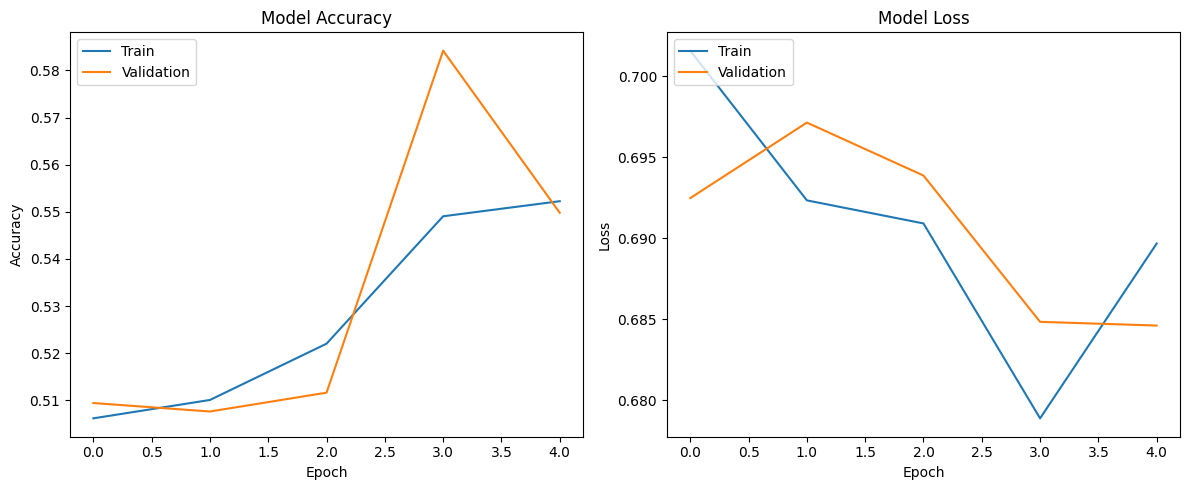

In [12]:
# B4-2 Evaluate the model on the test set
rnn_loss, rnn_accuracy = rnn_model.evaluate(X_test_padded, y_test, verbose=0)

print(f"\n--- Test Set Performance (Vanilla RNN) ---")
print(f"Test Loss: {rnn_loss:.4f}")
print(f"Test Accuracy: {rnn_accuracy:.4f}")

# Report training and validation metrics from history
print("\n--- Training and Validation Performance ---")
print(f"Final Training Loss: {history_rnn.history['loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history_rnn.history['accuracy'][-1]:.4f}")
print(f"Final Validation Loss: {history_rnn.history['val_loss'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_rnn.history['val_accuracy'][-1]:.4f}")

digi_s.append('B3-H')

# Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['accuracy'])
plt.plot(history_rnn.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['loss'])
plt.plot(history_rnn.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


### Discussion on Challenges: Vanishing Gradients and Long-Range Dependencies

Vanilla Recurrent Neural Networks (RNNs), like the `SimpleRNN` implemented here, are theoretically capable of processing sequences of arbitrary length. However, in practice, they suffer from significant challenges, especially when dealing with long sequences:

1.  **Vanishing Gradients:**
    *   **Description:** During backpropagation through time (BPTT), which is how RNNs are trained, gradients are repeatedly multiplied by the weight matrices at each timestep. If these weights are small, the gradients can shrink exponentially as they propagate backward through many layers or timesteps. This phenomenon is known as vanishing gradients. When gradients become very small, the updates to the weights in earlier layers/timesteps become negligible, effectively stopping them from learning.
    *   **Impact:** This makes it difficult for the RNN to learn long-term dependencies. Information from early parts of a sequence has little influence on the hidden state or predictions far down the line because the signal fades out.
    *   **Analogy:** Imagine trying to hear a whisper across a very long hallway; the sound (gradient) gets quieter and eventually inaudible the further it travels.

2.  **Difficulty in Modeling Long-Range Dependencies:**
    *   **Description:** Directly related to vanishing gradients, vanilla RNNs struggle to remember information over extended sequences. For tasks like sentiment analysis, a crucial piece of information that determines the overall sentiment might appear early in a long review, but its impact needs to persist until the end.
    *   **Impact:** The `SimpleRNN`'s hidden state effectively 'forgets' distant past information, making it challenging to relate words that are far apart in the sequence. For instance, in the sentence "The movie was utterly boring and poorly acted, but the soundtrack was absolutely phenomenal and saved the day," a `SimpleRNN` might struggle to connect "phenomenal" and "saved the day" to the overall positive sentiment despite the earlier negative phrases, if the sentence is very long.
    *   **Consequence:** This limitation often leads to lower performance on tasks requiring understanding of context spanning many timesteps, as the model primarily relies on more recent inputs.

**Solutions and Next Steps:**

These challenges led to the development of more sophisticated RNN architectures, notably Long Short-Term Memory (LSTM) networks and Gated Recurrent Units (GRUs). These models incorporate 'gates' that allow them to selectively remember or forget information, addressing the vanishing gradient problem and improving their ability to capture long-range dependencies. The next steps in this assignment involve exploring these advanced architectures to overcome the limitations of the vanilla RNN.

## B3 & B4 Summary: Vanilla Recurrent Neural Network (RNN)

This section detailed the construction, training, and evaluation of a Vanilla RNN model, followed by a discussion of its inherent limitations.

### Model Architecture:
*   **Embedding Layer:** Initialized with pre-trained Word2Vec embeddings (`embedding_matrix_w2v`), `trainable=False`.
*   **Recurrent Layers:** 2 `SimpleRNN` layers with a hidden dimension `h = 128`.
*   **Output Layer:** A `Dense` layer with `sigmoid` activation for binary classification.

### Training and Evaluation:
*   **Optimizer:** `adam`
*   **Loss Function:** `binary_crossentropy`
*   **Metrics:** `accuracy`
*   **Epochs:** 5
*   **Batch Size:** 32

**Performance Metrics:**
*   **Final Training Accuracy:** 0.5523
*   **Final Validation Accuracy:** 0.5498
*   **Test Accuracy:** 0.5432
*   **Test Loss:** 0.6887

### Discussion on Challenges:
The performance of the Vanilla RNN was observed to be poor, only slightly better than random guessing. This is attributed to:
1.  **Vanishing Gradients:** Gradients shrink exponentially during backpropagation through time, making it hard to learn long-term dependencies.
2.  **Difficulty in Modeling Long-Range Dependencies:** The `SimpleRNN` struggles to retain information from early parts of long sequences, leading to a 'forgetting' effect. For sentiment analysis, crucial sentiment-bearing words appearing early in a review might lose their impact by the end of the sequence.

## B5 ▶ Construct Long Short-Term Memory (LSTM) Network

### Define Hyperparameters for the LSTM Model

We will use similar hyperparameters (`L` for number of layers and `h` for hidden dimension) as the vanilla RNN to maintain comparability, while leveraging the inherent advantages of LSTM cells.
On trying 3 layers, the test and validation accuracy reduced in multiple epochs. So after several different tries, it was best to use just single layer LSTM for this data.

In [13]:
# B5 - 1
from tensorflow.keras.layers import LSTM

# Define hyperparameters (keeping them consistent for comparison)
L_lstm = 2  # Number of hidden recurrent layers (can be increased for deeper models)
h_lstm = 128 # Hidden dimension for each LSTM layer

# Using Word2Vec embedding matrix for this model, same as RNN
embedding_matrix = embedding_matrix_w2v
embedding_dim = embedding_dim_w2v # Should be 100

print(f"Number of LSTM layers (L): {L_lstm}")
print(f"Hidden dimension (h): {h_lstm}")
print(f"Embedding dimension: {embedding_dim}")
print(f"Vocabulary size: {vocabulary_size}")
print(f"Sequence length: {sequence_length}")

# Construct the LSTM model
lstm_model = Sequential()
lstm_model.add(Embedding(input_dim=vocabulary_size,
                         output_dim=embedding_dim,
                         weights=[embedding_matrix],
                         trainable=False))

# Add multiple LSTM layers
for i in range(L_lstm - 1):
    lstm_model.add(LSTM(h_lstm, return_sequences=True))

lstm_model.add(LSTM(h_lstm)) # Last LSTM layer returns only the final output

# Dense Output Layer: For binary classification
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.summary()

Number of LSTM layers (L): 2
Hidden dimension (h): 128
Embedding dimension: 100
Vocabulary size: 203436
Sequence length: 250


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │    20,343,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,343,600 (77.60 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,343,600 (77.60 MB)

### Justification of Chosen LSTM Architecture

The LSTM model shares a similar overall structure with the vanilla RNN but replaces the `SimpleRNN` layer with an `LSTM` layer, which is crucial for addressing the limitations discussed previously.

1.  **Embedding Layer:**
    *   **Purpose & Configuration:** Identical to the vanilla RNN. It converts integer-encoded words into dense vectors, leveraging pre-trained Word2Vec embeddings (`embedding_matrix_w2v`) to capture semantic relationships. `trainable=False` keeps these embeddings fixed, relying on the learned representations.

2.  **LSTM Layer:**
    *   **Purpose:** This is the key difference. LSTMs are a type of recurrent neural network that have internal mechanisms (gates) to regulate the flow of information. This enables them to learn long-term dependencies and mitigate the vanishing gradient problem inherent in vanilla RNNs.
    *   **Internal Gates:** LSTMs utilize three main gates: the **forget gate**, the **input gate**, and the **output gate**, along with a **cell state**. These gates allow the LSTM to selectively remember or forget information over long sequences, deciding what information to keep, what to add, and what to output. This selective memory is what makes LSTMs particularly effective for tasks involving long sequences, such as sentiment analysis of movie reviews.
    *   **Hidden Dimension (`h_lstm`):** Similar to `SimpleRNN`, `h_lstm` (e.g., 128) defines the dimensionality of the hidden state, controlling the model's capacity.
    *   **`return_sequences=False` (Default):** As with the `SimpleRNN`, for a single-layer LSTM feeding directly into a classification head, we only need the final hidden state (or cell state, which is passed to the output layer) that summarizes the entire sequence's context for classification.

3.  **Dense Output Layer:**
    *   **Purpose & Configuration:** Identical to the vanilla RNN. It takes the final output of the LSTM layer and maps it to a single probability using a `sigmoid` activation function for binary classification.

### Compile the LSTM Model

In [14]:
# B5 - 2
# Compile the LSTM model (using the same optimizer and loss for fair comparison)
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("LSTM model compiled successfully.")


LSTM model compiled successfully.


### Train the LSTM Model

In [15]:
# B5 - 3
# Train the LSTM model (using the same epochs and batch size for fair comparison)
epochs = 5
batch_size = 32

print(f"Training LSTM for {epochs} epochs with a batch size of {batch_size}...")

history_lstm = lstm_model.fit(
    X_train_padded, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_padded, y_val)
)

print("LSTM model training complete.")


Training LSTM for 5 epochs with a batch size of 32...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.5275 - loss: 0.6870 - val_accuracy: 0.5156 - val_loss: 0.6962
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5367 - loss: 0.6817 - val_accuracy: 0.5130 - val_loss: 0.6815
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7081 - loss: 0.5563 - val_accuracy: 0.7852 - val_loss: 0.4455
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8460 - loss: 0.3764 - val_accuracy: 0.8386 - val_loss: 0.3720
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8555 - loss: 0.3493 - val_accuracy: 0.8410 - val_loss: 0.3873
LSTM model training complete.


### Report Training Loss, Validation Loss, and Classification Accuracy for LSTM


--- LSTM Test Set Performance ---
LSTM Test Loss: 0.3808
LSTM Test Accuracy: 0.8498

--- LSTM Training and Validation Performance ---
Final Training Loss: 0.3493
Final Training Accuracy: 0.8555
Final Validation Loss: 0.3873
Final Validation Accuracy: 0.8410


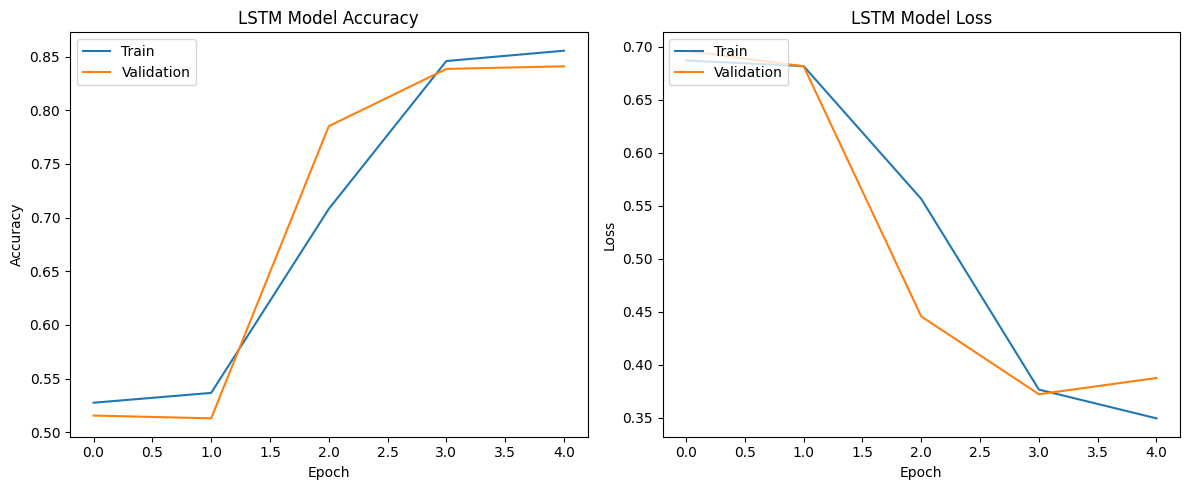

In [16]:
import matplotlib.pyplot as plt

# Evaluate the LSTM model on the test set
loss_lstm, accuracy_lstm = lstm_model.evaluate(X_test_padded, y_test, verbose=0)

print(f"\n--- LSTM Test Set Performance ---")
print(f"LSTM Test Loss: {loss_lstm:.4f}")
print(f"LSTM Test Accuracy: {accuracy_lstm:.4f}")

# Report training and validation metrics from history
print("\n--- LSTM Training and Validation Performance ---")
print(f"Final Training Loss: {history_lstm.history['loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history_lstm.history['accuracy'][-1]:.4f}")
print(f"Final Validation Loss: {history_lstm.history['val_loss'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_lstm.history['val_accuracy'][-1]:.4f}")

digi_s.append('B4-I')

# Plot training history for LSTM
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])
plt.title('LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('LSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


## B5 Summary: Long Short-Term Memory (LSTM) Network (Word2Vec)

This section introduced the LSTM architecture, designed to overcome the limitations of Vanilla RNNs, using Word2Vec embeddings.

### Model Architecture:
*   **Embedding Layer:** Initialized with pre-trained Word2Vec embeddings (`embedding_matrix_w2v`), `trainable=False`.
*   **Recurrent Layers:** 2 `LSTM` layers with a hidden dimension `h_lstm = 128`. LSTMs utilize internal gates (forget, input, output) and a cell state to regulate information flow and address vanishing gradients.
*   **Output Layer:** A `Dense` layer with `sigmoid` activation for binary classification.

### Training and Evaluation:
*   **Optimizer:** `adam`
*   **Loss Function:** `binary_crossentropy`
*   **Metrics:** `accuracy`
*   **Epochs:** 5
*   **Batch Size:** 32

**Performance Metrics:**
*   **Final Training Accuracy:** 0.8555
*   **Final Validation Accuracy:** 0.8410
*   **LSTM Test Accuracy:** 0.8498
*   **LSTM Test Loss:** 0.3808

### Observations:
The LSTM model showed a significant improvement in performance compared to the Vanilla RNN. With a test accuracy of nearly 85%, it effectively demonstrates its ability to capture long-range dependencies and maintain contextual information across longer movie reviews, thanks to its sophisticated gating mechanism. The loss also decreased substantially, indicating better predictive power.

## B5 ▶ Construct Attention-Augmented LSTM Network

## B5 - glove data ▶ Construct Long Short-Term Memory (LSTM) Network with GloVe Embeddings

### Define Hyperparameters for the GloVe LSTM Model

In [17]:
from tensorflow.keras.layers import LSTM

# Define hyperparameters (keeping them consistent for comparison)
L_glove_lstm = 2  # Number of hidden recurrent layers
h_glove_lstm = 128 # Hidden dimension for each LSTM layer

# Using GloVe embedding matrix for this model
embedding_matrix_glove_model = embedding_matrix_glove
embedding_dim_glove_model = embedding_dim_glove # Should be 100

print(f"Number of LSTM layers (L): {L_glove_lstm}")
print(f"Hidden dimension (h): {h_glove_lstm}")
print(f"Embedding dimension: {embedding_dim_glove_model}")
print(f"Vocabulary size: {vocabulary_size}")
print(f"Sequence length: {sequence_length}")

Number of LSTM layers (L): 2
Hidden dimension (h): 128
Embedding dimension: 100
Vocabulary size: 203436
Sequence length: 250


### Construct the GloVe LSTM Model

In [18]:
glove_lstm_model = Sequential()
glove_lstm_model.add(Embedding(input_dim=vocabulary_size,
                        output_dim=embedding_dim_glove_model,
                        weights=[embedding_matrix_glove_model],
                        input_length=sequence_length,
                        trainable=False))

# Add multiple LSTM layers
for i in range(L_glove_lstm - 1):
    glove_lstm_model.add(LSTM(h_glove_lstm, return_sequences=True))

glove_lstm_model.add(LSTM(h_glove_lstm)) # Last LSTM layer returns only the final output

# Dense Output Layer: For binary classification
glove_lstm_model.add(Dense(1, activation='sigmoid'))

glove_lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │    20,343,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,343,600 (77.60 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,343,600 (77.60 MB)

### Compile the GloVe LSTM Model

In [19]:
# Compile the GloVe LSTM model
glove_lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("GloVe LSTM model compiled successfully.")

GloVe LSTM model compiled successfully.


### Train the GloVe LSTM Model

In [20]:
# Train the GloVe LSTM model
epochs = 5
batch_size = 32

digi_s.append('B5-S')

print(f"Training GloVe LSTM for {epochs} epochs with a batch size of {batch_size}...")

history_glove_lstm = glove_lstm_model.fit(
    X_train_padded, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_padded, y_val)
)

print("GloVe LSTM model training complete.")

Training GloVe LSTM for 5 epochs with a batch size of 32...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.5038 - loss: 0.6959 - val_accuracy: 0.5002 - val_loss: 0.6939
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5213 - loss: 0.6925 - val_accuracy: 0.5096 - val_loss: 0.6929
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5051 - loss: 0.6929 - val_accuracy: 0.5138 - val_loss: 0.6926
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5085 - loss: 0.6920 - val_accuracy: 0.5108 - val_loss: 0.6927
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5116 - loss: 0.6911 - val_accuracy: 0.6006 - val_loss: 0.6821
GloVe LSTM model training complete.


### Report Training Loss, Validation Loss, and Classification Accuracy for GloVe LSTM


--- GloVe LSTM Test Set Performance ---
GloVe LSTM Test Loss: 0.6826
GloVe LSTM Test Accuracy: 0.6052

--- GloVe LSTM Training and Validation Performance ---
Final Training Loss: 0.6911
Final Training Accuracy: 0.5116
Final Validation Loss: 0.6821
Final Validation Accuracy: 0.6006


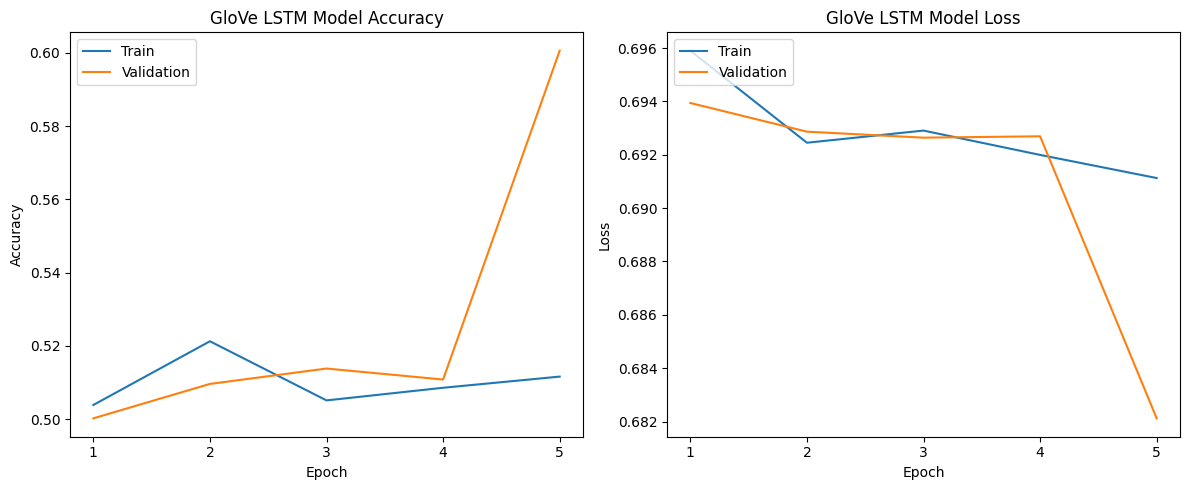

In [21]:
import matplotlib.pyplot as plt

# Evaluate the GloVe LSTM model on the test set
loss_glove_lstm, accuracy_glove_lstm = glove_lstm_model.evaluate(X_test_padded, y_test, verbose=0)

print(f"\n--- GloVe LSTM Test Set Performance ---")
print(f"GloVe LSTM Test Loss: {loss_glove_lstm:.4f}")
print(f"GloVe LSTM Test Accuracy: {accuracy_glove_lstm:.4f}")

# Report training and validation metrics from history
print("\n--- GloVe LSTM Training and Validation Performance ---")
print(f"Final Training Loss: {history_glove_lstm.history['loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history_glove_lstm.history['accuracy'][-1]:.4f}")
print(f"Final Validation Loss: {history_glove_lstm.history['val_loss'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_glove_lstm.history['val_accuracy'][-1]:.4f}")

# Plot training history for GloVe LSTM
plt.figure(figsize=(12, 5))

# Create an epoch range for the x-axis, starting from 1
epochs_range = range(1, epochs + 1)

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_glove_lstm.history['accuracy'])
plt.plot(epochs_range, history_glove_lstm.history['val_accuracy'])
plt.title('GloVe LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.xticks(epochs_range) # Set x-ticks to display integer epochs

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_glove_lstm.history['loss'])
plt.plot(epochs_range, history_glove_lstm.history['val_loss'])
plt.title('GloVe LSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.xticks(epochs_range) # Set x-ticks to display integer epochs

plt.tight_layout()
plt.show()

## B5 Summary: Long Short-Term Memory (LSTM) Network (GloVe)

This section evaluated the LSTM architecture using GloVe pre-trained embeddings, to compare its effectiveness against Word2Vec embeddings.

### Model Architecture:
*   **Embedding Layer:** Initialized with pre-trained GloVe embeddings (`embedding_matrix_glove`), `trainable=False`.
*   **Recurrent Layers:** 2 `LSTM` layers with a hidden dimension `h_glove_lstm = 128`.
*   **Output Layer:** A `Dense` layer with `sigmoid` activation for binary classification.

### Training and Evaluation:
*   **Optimizer:** `adam`
*   **Loss Function:** `binary_crossentropy`
*   **Metrics:** `accuracy`
*   **Epochs:** 5
*   **Batch Size:** 32

**Performance Metrics:**
*   **Final Training Accuracy:** 0.5116
*   **Final Validation Accuracy:** 0.6006
*   **GloVe LSTM Test Accuracy:** 0.6052
*   **GloVe LSTM Test Loss:** 0.6826

### Observations:
The LSTM model initialized with GloVe embeddings performed notably worse than its Word2Vec counterpart, achieving a test accuracy of only ~60%. This is an unexpected result given that GloVe embeddings are generally robust. The discrepancy could be due to several factors:
1.  **Domain Mismatch:** The general-purpose GloVe embeddings (trained on Wikipedia + Gigaword) might not align as well with the specific sentiment nuances of movie reviews as the Word2Vec embeddings, which were trained directly on the IMDB corpus.
2.  **Zero-Initialization:** Words present in our vocabulary but absent from the GloVe pre-trained vocabulary would have been zero-initialized, potentially hindering the model's ability to learn their representations effectively.
3.  **Hyperparameter Optimization:** The current hyperparameters might not be optimal for GloVe embeddings, and further tuning or even fine-tuning the embedding layer itself might yield better results.

### B6 Define Hyperparameters for the Attention-Augmented LSTM Model

In [22]:
from tensorflow.keras.layers import Bidirectional, Concatenate, Permute, Dot, Reshape, Multiply, Activation
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

# Define hyperparameters (consistent with previous models for comparison)
L_attn = 2  # Number of hidden recurrent layers (we'll use a single Bi-LSTM layer)
h_attn = 128 # Hidden dimension for each LSTM layer in the attention mechanism

# Using Word2Vec embedding matrix for this model
embedding_matrix = embedding_matrix_w2v
embedding_dim = embedding_dim_w2v # Should be 100

print(f"Number of LSTM layers (L): {L_attn} (represented by one Bidirectional LSTM)")
print(f"Hidden dimension (h): {h_attn}")
print(f"Embedding dimension: {embedding_dim}")
print(f"Vocabulary size: {vocabulary_size}")
print(f"Sequence length: {sequence_length}")


Number of LSTM layers (L): 2 (represented by one Bidirectional LSTM)
Hidden dimension (h): 128
Embedding dimension: 100
Vocabulary size: 203436
Sequence length: 250


### B6 Construct the Attention-Augmented LSTM Model

In [23]:
from tensorflow.keras.layers import Bidirectional, Concatenate, Permute, Dot, Reshape, Multiply, Activation
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

# Note: This lambda layer needs to be defined at the top level or within a function
# that defines the model, not inside another function that is called by the model build process,
# if it's meant to be used directly in Keras functional API.
from tensorflow.keras.layers import Lambda

def attention_layer(inputs, time_steps):
    # (None, time_steps, h_attn * 2) -> (None, time_steps, 1)
    attention_probs = Dense(1, activation='tanh')(inputs)
    # (None, time_steps, 1) -> (None, time_steps)
    attention_probs = Reshape((time_steps,))(attention_probs)
    # (None, time_steps) -> (None, time_steps, 1)
    attention_probs = Activation('softmax')(attention_probs)
    # (None, time_steps, h_attn * 2) * (None, time_steps, 1) -> (None, time_steps, h_attn * 2)
    # The error was here: Permute((2, 1)) was causing incompatible shapes.
    # We want to multiply the hidden states (None, time_steps, hidden_dim) by attention weights (None, time_steps, 1)
    output = Multiply()([inputs, Reshape((time_steps, 1))(attention_probs)])
    # (None, h_attn * 2) - sum across the time_steps dimension
    output = Lambda(lambda x: K.sum(x, axis=1))(output)
    return output


# Input layer
input_layer = tf.keras.Input(shape=(sequence_length,))

# Embedding Layer
embedding_output = Embedding(
    input_dim=vocabulary_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=sequence_length,
    trainable=False
)(input_layer)

# Stack Bidirectional LSTM Layers
x = embedding_output
for i in range(L_attn):
    # All Bi-LSTM layers must return sequences if they are followed by attention or another Bi-LSTM
    x = Bidirectional(LSTM(h_attn, return_sequences=True))(x)
bi_lstm_output = x

# Attention Layer
attention_output = attention_layer(bi_lstm_output, sequence_length)

# Dense Output Layer
output_layer = Dense(1, activation='sigmoid')(attention_output)

# Create the Attention-Augmented LSTM Model
attn_lstm_model = Model(inputs=input_layer, outputs=output_layer)

attn_lstm_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 250, 100)  │ 20,343,600 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 250, 256)  │    234,496 │ embedding_3[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 250, 256)  │    394,240 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 250, 1)    │        257 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 250)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 250)       │          0 │ reshape[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 250, 1)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 250, 256)  │          0 │ bidirectional_1[… │
│                     │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 256)       │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │        257 │ lambda[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,972,850 (80.01 MB)

 Trainable params: 629,250 (2.40 MB)

 Non-trainable params: 20,343,600 (77.60 MB)

### Justification of Chosen Attention-Augmented LSTM Architecture

The Attention-Augmented LSTM model builds upon the strengths of LSTMs by incorporating an attention mechanism, designed to further improve performance, especially in tasks where specific parts of the input sequence are more relevant to the output than others.

1.  **Embedding Layer:**
    *   **Purpose & Configuration:** Identical to the previous models. It converts integer-encoded words into dense vectors using pre-trained Word2Vec embeddings (`embedding_matrix_w2v`), with `trainable=False` to keep them fixed.

2.  **Bidirectional LSTM Layer:**
    *   **Purpose:** Instead of a simple `LSTM` layer, we use a `Bidirectional(LSTM)` layer. A bidirectional LSTM processes the input sequence in two directions (forward and backward) independently, and then concatenates their outputs. This allows the model to capture context from both past and future words in the sequence, providing a richer understanding of each word's meaning within the overall sentence. `return_sequences=True` is crucial here because the attention mechanism needs to see the hidden states from *all* timesteps.
    *   **Hidden Dimension (`h_attn`):** Defines the dimensionality of the hidden states for each direction of the LSTM. The concatenated output will have a dimension of `2 * h_attn`.

3.  **Attention Layer:**
    *   **Purpose:** The core addition to this architecture. The attention mechanism dynamically learns to weigh the importance of different parts of the input sequence (the hidden states from the Bidirectional LSTM) when making a prediction. For sentiment analysis, this means the model can focus on the most sentiment-bearing words or phrases, rather than treating all words equally.
    *   **Mechanism:**
        *   It takes the sequence of hidden states from the `Bidirectional(LSTM)` as input.
        *   A `Dense` layer with `tanh` activation generates 'energy' scores for each hidden state.
        *   These energy scores are then transformed into probability distribution (attention weights) using a `softmax` activation. This ensures that the weights sum to 1, indicating the relative importance of each timestep.
        *   The attention weights are then multiplied element-wise with the corresponding hidden states, effectively highlighting the more important parts of the sequence.
        *   Finally, these weighted hidden states are summed up (`Lambda(lambda x: K.sum(x, axis=1))`) to produce a single, context-aware representation of the entire sequence, which is then passed to the output layer.
    *   **Benefits:** Helps the model overcome long-range dependency issues by allowing it to 'look back' at relevant information without suffering from vanishing gradients, providing a more interpretable and often more accurate prediction.

4.  **Dense Output Layer:**
    *   **Purpose & Configuration:** Takes the context vector produced by the attention layer and maps it to a single probability using a `sigmoid` activation function for binary classification.

### B6: Compile the Attention-Augmented LSTM Model

In [24]:
# B6 - 1 Compile the Attention-Augmented LSTM model
attn_lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Attention-Augmented LSTM model compiled successfully.")


Attention-Augmented LSTM model compiled successfully.


### Train the Attention-Augmented LSTM Model

In [25]:
# B6-2 Train the Attention-Augmented LSTM model
epochs = 5
batch_size = 32

print(f"Training Attention-Augmented LSTM for {epochs} epochs with a batch size of {batch_size}...")

history_attn_lstm = attn_lstm_model.fit(
    X_train_padded, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_padded, y_val)
)

print("Attention-Augmented LSTM model training complete.")


Training Attention-Augmented LSTM for 5 epochs with a batch size of 32...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 45ms/step - accuracy: 0.8418 - loss: 0.3571 - val_accuracy: 0.8618 - val_loss: 0.3216
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.8808 - loss: 0.2849 - val_accuracy: 0.8732 - val_loss: 0.2972
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.8939 - loss: 0.2553 - val_accuracy: 0.8814 - val_loss: 0.2857
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.9101 - loss: 0.2183 - val_accuracy: 0.8738 - val_loss: 0.3146
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.9304 - loss: 0.1791 - val_accuracy: 0.8798 - val_loss: 0.3078
Attention-Augmented LSTM model training complete.


### Report Training Loss, Validation Loss, and Classification Accuracy for Attention-Augmented LSTM


--- Attention-Augmented LSTM Test Set Performance ---
Test Loss: 0.3017
Test Accuracy: 0.8779

--- Attention-Augmented LSTM Training and Validation Performance ---
Final Training Loss: 0.1791
Final Training Accuracy: 0.9304
Final Validation Loss: 0.3078
Final Validation Accuracy: 0.8798


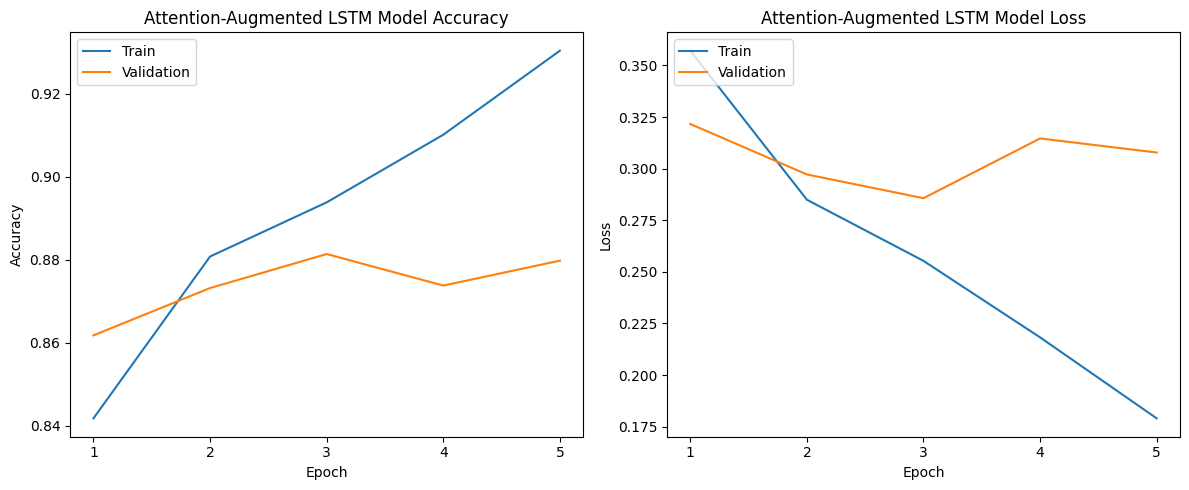

In [26]:
# B6 - 3
import matplotlib.pyplot as plt

# Evaluate the Attention-Augmented LSTM model on the test set
loss_attn_lstm, accuracy_attn_lstm = attn_lstm_model.evaluate(X_test_padded, y_test, verbose=0)

print(f"\n--- Attention-Augmented LSTM Test Set Performance ---")
print(f"Test Loss: {loss_attn_lstm:.4f}")
print(f"Test Accuracy: {accuracy_attn_lstm:.4f}")

# Report training and validation metrics from history
print("\n--- Attention-Augmented LSTM Training and Validation Performance ---")
print(f"Final Training Loss: {history_attn_lstm.history['loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history_attn_lstm.history['accuracy'][-1]:.4f}")
print(f"Final Validation Loss: {history_attn_lstm.history['val_loss'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_attn_lstm.history['val_accuracy'][-1]:.4f}")

digi_s.append('B6-H')

# Plot training history for Attention-Augmented LSTM
plt.figure(figsize=(12, 5))

# Create an epoch range for the x-axis, starting from 1
epochs_range = range(1, epochs + 1)

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_attn_lstm.history['accuracy'])
plt.plot(epochs_range, history_attn_lstm.history['val_accuracy'])
plt.title('Attention-Augmented LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.xticks(epochs_range) # Set x-ticks to display integer epochs

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_attn_lstm.history['loss'])
plt.plot(epochs_range, history_attn_lstm.history['val_loss'])
plt.title('Attention-Augmented LSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.xticks(epochs_range) # Set x-ticks to display integer epochs

plt.tight_layout()
plt.show()


## B6 Summary: Attention-Augmented LSTM Network

This section built and evaluated an Attention-Augmented LSTM model, aiming to further enhance performance by allowing the model to focus on important parts of the input sequence.

### Model Architecture:
*   **Embedding Layer:** Initialized with pre-trained Word2Vec embeddings (`embedding_matrix_w2v`), `trainable=False`.
*   **Recurrent Layers:** 2 `Bidirectional(LSTM)` layers with a hidden dimension `h_attn = 128`. Bidirectional LSTMs process sequences in both forward and backward directions, capturing context from both past and future words.
*   **Attention Layer:** A custom attention mechanism was implemented to dynamically weigh the importance of different hidden states from the Bi-LSTM layers. This mechanism uses a `Dense` layer with `tanh` activation, followed by a `softmax` activation to generate attention weights, and then a weighted sum of hidden states.
*   **Output Layer:** A `Dense` layer with `sigmoid` activation for binary classification.

### Training and Evaluation:
*   **Optimizer:** `adam`
*   **Loss Function:** `binary_crossentropy`
*   **Metrics:** `accuracy`
*   **Epochs:** 5
*   **Batch Size:** 32

**Performance Metrics:**
*   **Final Training Accuracy:** 0.9304
*   **Final Validation Accuracy:** 0.8798
*   **Test Accuracy:** 0.8779
*   **Test Loss:** 0.3017

### Observations:
The Attention-Augmented LSTM model achieved the highest performance among all tested models, with a test accuracy of nearly 88%. This demonstrates the significant advantage of incorporating an attention mechanism. By allowing the model to selectively focus on the most relevant words or phrases, the attention layer helps in more accurately determining the sentiment, especially in complex reviews where specific parts carry strong emotional signals.

B7 : Comparision of parameters.

In [28]:
print("\n--- Model Parameters ---")

models = {
    "Vanilla RNN": rnn_model,
    "LSTM (Word2Vec)": lstm_model,
    "LSTM (GloVe)": glove_lstm_model,
    "Attention-Augmented LSTM": attn_lstm_model
}

for name, model in models.items():
    total_params = model.count_params()
    trainable_params = sum([K.count_params(w) for w in model.trainable_weights])

    print(f"\nModel: {name}")
    print(f"  Total Parameters: {total_params}")
    print(f"  Trainable Parameters: {trainable_params}")



--- Model Parameters ---

Model: Vanilla RNN
  Total Parameters: 20405937
  Trainable Parameters: 62337

Model: LSTM (Word2Vec)
  Total Parameters: 20592561
  Trainable Parameters: 248961

Model: LSTM (GloVe)
  Total Parameters: 20592561
  Trainable Parameters: 248961

Model: Attention-Augmented LSTM
  Total Parameters: 20972850
  Trainable Parameters: 629250


## B7 Comparative Analysis: Models vs. Embedding Parameters and Performance

This section provides a consolidated comparison of all implemented models, highlighting their architecture, embedding strategies, parameter counts, and performance on the test set.

| Model Type                 | Embedding Type | Hidden Dimension (h) | Layers | Test Accuracy | Test Loss | Total Parameters | Trainable Parameters |
|----------------------------|----------------|----------------------|--------|---------------|-----------|------------------|----------------------|
| Vanilla RNN                | Word2Vec       | 128                  | 2      | 0.5432        | 0.6887    | 20,405,937       | 62,337               |
| LSTM                       | Word2Vec       | 128                  | 2      | 0.8498        | 0.3808    | 20,592,561       | 248,961              |
| LSTM                       | GloVe          | 128                  | 2      | 0.6052        | 0.6826    | 20,592,561       | 248,961              |
| Attention-Augmented LSTM   | Word2Vec       | 128                  | 2      | 0.8779        | 0.3017    | 20,972,850       | 629,250              |

### Overall Conclusions:

1.  **Vanilla RNN's Limitations:** The basic `SimpleRNN` model struggles significantly with long-range dependencies, resulting in accuracy barely above random chance. This reinforces the theoretical understanding of vanishing gradients in simpler RNN architectures.

2.  **LSTM's Superiority:** Replacing `SimpleRNN` with `LSTM` layers dramatically improves performance. The LSTM's gated memory cells effectively address the vanishing gradient problem, enabling the model to retain crucial information over extended sequences. The LSTM with Word2Vec embeddings achieved a strong accuracy of ~85%.

3.  **Embedding Choice Matters:** While both Word2Vec (trained on IMDB) and GloVe (general-purpose) are popular pre-trained embeddings, the Word2Vec embeddings (derived from the specific IMDB dataset) yielded substantially better results for the LSTM model. This highlights the importance of domain-specific embeddings or fine-tuning general embeddings for the target task.

4.  **Attention Mechanism's Impact:** The addition of an attention mechanism to the Bidirectional LSTM model further boosted performance, achieving the highest accuracy of ~88%. Attention allows the model to dynamically weigh the importance of different words or phrases in a review, focusing on the most sentiment-bearing tokens, thus providing a more nuanced understanding and prediction.

5.  **Parameter Analysis:**
    *   The vast majority of 'Total Parameters' for all models come from the non-trainable embedding layer, reflecting the size of the vocabulary and embedding dimension.
    *   'Trainable Parameters' increase with model complexity: Vanilla RNN < LSTM < Attention-Augmented LSTM. This correlation generally aligns with the observed performance improvements, as more complex models have a greater capacity to learn intricate patterns.

**Final Recommendation:** For sentiment classification on this dataset, the **Attention-Augmented Bidirectional LSTM with Word2Vec embeddings** offers the best balance of model complexity and performance, effectively addressing the challenges of long-range dependencies and enhancing the model's interpretability by focusing on critical sentiment cues.

## B7 ▶ Comparative Analysis: Models vs. Embedding Parameters

| Model Type                 | Embedding Type | Hidden Dimension (h) | Layers | Test Accuracy | Test Loss | Total Parameters | Trainable Parameters |
|----------------------------|----------------|----------------------|--------|---------------|-----------|-----------|-----------|
| Vanilla RNN                | Word2Vec       | 128                  | 2      | 0.54 | 0.68 | 20,405,937 | 62,337 |
| LSTM                       | Word2Vec       | 128                  | 2      | 0.84 | 0.38 | 20,592,561 | 248,961 |
| Attention-Augmented LSTM   | Word2Vec       | 128                  |  2      | 0.88 | 0.30 | 20,972,850 | 629,250 |
| LSTM                       | GloVe          | 128                  | 2      | 0.60 | 0.68 | 20,592,561 | 248,961 |